# practice in class feature selection

In [ ]:
# pip install feature-engine

In [ ]:
# pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.3/562.3 kB 11.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 60.6 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# importing libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score, classification_report
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.preprocessing import PolynomialFeatures

In [21]:
# importing the data
adult = pd.read_csv("adult.csv")
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [22]:
# preparing the data for modeling

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# drop the fnlwgt variable as it is not useful for modeling
adult.drop(columns=["fnlwgt"], inplace=True)

# gender to binary
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)

# replace ? with NaN
adult.replace("?", np.nan, inplace=True)

# impute missing values as average in numerical and "unknown" in categorical
for col in adult.columns:
    if adult[col].dtype == "object":
        adult[col] = adult[col].fillna("unknown")
    else:
        adult[col] = adult[col].fillna(adult[col].median())
        
adult.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,unknown,Some-college,10,Never-married,unknown,Own-child,White,0,0,0,30,United-States,0


In [37]:
# Feature Preprocessing with Feature-engine

from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.model_selection import train_test_split

# copy data
df_fe = adult.copy()

# split features/target
X = df_fe.drop("income", axis=1)
y = df_fe["income"]

# split data
X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# identify variable types
cat_cols = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

# collapse rare categories
rare_encoder = RareLabelEncoder(
    tol=0.01,
    variables=cat_cols
)

X_train_fe = rare_encoder.fit_transform(X_train_fe)
X_test_fe = rare_encoder.transform(X_test_fe)

# frequency encode categorical variables
freq_encoder = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")

X_train_fe = freq_encoder.fit_transform(X_train_fe)
X_test_fe = freq_encoder.transform(X_test_fe)

# exclude problematic variables from discretization
disc_vars = [col for col in num_cols if col not in ["gender", "capital-gain", "capital-loss"]]

# discretize remaining numeric variables
disc = EqualFrequencyDiscretiser(
    q=5,
    variables=disc_vars
)

X_train_fe = disc.fit_transform(X_train_fe)
X_test_fe = disc.transform(X_test_fe)

# drop constant features if any were created
const_drop = DropConstantFeatures()

X_train_fe = const_drop.fit_transform(X_train_fe)
X_test_fe = const_drop.transform(X_test_fe)

print("Original shape:", X.shape)
print("Transformed train shape:", X_train_fe.shape)

X_train_fe.head(20)

Original shape: (48842, 13)
Transformed train shape: (39073, 13)


/opt/anaconda3/envs/pyenv312/lib/python3.12/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable workclass is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/opt/anaconda3/envs/pyenv312/lib/python3.12/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable marital-status is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/opt/anaconda3/envs/pyenv312/lib/python3.12/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable relationship is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/opt/anaconda3/envs/pyenv312/lib/python3.12/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for va

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
34342,4,0.693727,0.324751,0,0.330945,0.042664,0.258618,0.85609,1,0,0,0,0.898344
18559,0,0.693727,0.028613,0,0.330945,0.113122,0.031352,0.85609,0,0,0,0,0.898344
12477,1,0.693727,0.324751,0,0.456632,0.101144,0.402580,0.85609,1,0,0,1,0.064699
560,3,0.693727,0.324751,0,0.031684,0.115067,0.105239,0.09513,0,0,0,1,0.898344
3427,1,0.693727,0.164257,2,0.456632,0.125278,0.402580,0.85609,1,0,0,1,0.898344
40152,0,0.693727,0.220920,1,0.330945,0.042664,0.154890,0.85609,1,0,0,0,0.898344
23445,0,0.056919,0.220920,1,0.330945,0.057175,0.154890,0.85609,0,0,0,0,0.898344
30132,3,0.693727,0.324751,0,0.456632,0.113122,0.402580,0.85609,1,0,0,1,0.898344
44628,3,0.029458,0.324751,0,0.330945,0.115067,0.105239,0.85609,0,0,0,1,0.898344
18571,0,0.693727,0.324751,0,0.330945,0.042664,0.154890,0.85609,0,0,1719,0,0.898344


In [38]:
print("Dropped constant features:", const_drop.features_to_drop_)

Dropped constant features: []


In [39]:
rare_encoder.encoder_dict_

{'workclass': ['Private',
  'unknown',
  'Federal-gov',
  'Local-gov',
  'State-gov',
  'Self-emp-not-inc',
  'Self-emp-inc',
  'Never-worked',
  'Without-pay'],
 'education': ['HS-grad',
  'Some-college',
  'Bachelors',
  'Masters',
  'Assoc-voc',
  '11th',
  'Assoc-acdm',
  '10th',
  '7th-8th',
  'Prof-school',
  '9th',
  '12th',
  'Doctorate',
  '5th-6th'],
 'marital-status': ['Never-married',
  'Married-civ-spouse',
  'Separated',
  'Divorced',
  'Widowed',
  'Married-AF-spouse',
  'Married-spouse-absent'],
 'occupation': ['Prof-specialty',
  'Craft-repair',
  'Exec-managerial',
  'Adm-clerical',
  'Sales',
  'Other-service',
  'Machine-op-inspct',
  'unknown',
  'Transport-moving',
  'Handlers-cleaners',
  'Farming-fishing',
  'Tech-support',
  'Protective-serv'],
 'relationship': ['Not-in-family',
  'Other-relative',
  'Husband',
  'Unmarried',
  'Own-child',
  'Wife'],
 'race': ['White',
  'Black',
  'Amer-Indian-Eskimo',
  'Other',
  'Asian-Pac-Islander'],
 'native-country': ['

### Baseline models with transformed original features

In [58]:
# baseline random forest and xgboost CV models using X_train_fe and X_test_fe datasets

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# baseline random forest with class imbalance handling and CV with default parameters
rf_baseline_fe = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cv_scores = cross_val_score(rf_baseline_fe, X_train_fe, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores:", rf_cv_scores)
rf_baseline_fe.fit(X_train_fe, y_train)
rf_preds_fe = rf_baseline_fe.predict(X_test_fe)
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))

# baseline xgboost with class imbalance handling and CV with default parameters

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos

xgb_baseline_fe = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores = cross_val_score(xgb_baseline_fe, X_train_fe, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost adult_fe CV Balanced Accuracy Scores:", xgb_cv_scores)    
xgb_baseline_fe.fit(X_train_fe, y_train)
xgb_preds_fe = xgb_baseline_fe.predict(X_test_fe)
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe)) 

Random Forest CV Balanced Accuracy Scores: [0.80039376 0.80307251 0.79647594 0.79548456 0.78734085]
Random Forest adult_fe Test Balanced Accuracy: 0.8028377756281657
XGBoost adult_fe CV Balanced Accuracy Scores: [0.84003027 0.84400453 0.84304925 0.83938866 0.8385428 ]
XGBoost adult_fe Test Balanced Accuracy: 0.8407010306050337


In [52]:
# Rank and display feature importances from baseline models using adult_fe data
rf_importances = pd.Series(rf_baseline_fe.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
xgb_importances = pd.Series(xgb_baseline_fe.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
print("Top 10 Random Forest Feature Importances:")
print(rf_importances.head(10))
print("\nTop 10 XGBoost Feature Importances:")
print(xgb_importances.head(10))


Top 10 Random Forest Feature Importances:
marital-status     0.185764
relationship       0.141100
occupation         0.114200
age                0.108124
capital-gain       0.104071
educational-num    0.079628
hours-per-week     0.059954
education          0.055840
workclass          0.055175
capital-loss       0.036133
dtype: float64

Top 10 XGBoost Feature Importances:
marital-status     0.413783
educational-num    0.170484
capital-gain       0.120274
capital-loss       0.054321
age                0.047981
hours-per-week     0.043268
occupation         0.035629
education          0.026873
gender             0.026502
relationship       0.020360
dtype: float32


In [ ]:
# Rank and display permutation importances for baseline models using adult_fe data

rf_perm_importance = permutation_importance(rf_baseline_fe, X_test_fe, y_test, n_repeats=10, random_state=42)
xgb_perm_importance = permutation_importance(xgb_baseline_fe, X_test_fe, y_test, n_repeats=10, random_state=42)

# saving permutation importance results in DataFrames for easier display
rf_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': rf_perm_importance.importances_mean,
    'importance_std': rf_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)
xgb_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': xgb_perm_importance.importances_mean,
    'importance_std': xgb_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

# display top 10 features by permutation importance for both models
print("Top 10 Random Forest Permutation Importances:")
print(rf_perm_importance_df.head(10))
print("\nTop 10 XGBoost Permutation Importances:")
print(xgb_perm_importance_df.head(10))

Top 10 Random Forest Permutation Importances:
            feature  importance_mean  importance_std
9      capital-gain         0.042778        0.001170
4    marital-status         0.019828        0.002051
3   educational-num         0.018753        0.002620
0               age         0.016143        0.003046
5        occupation         0.015969        0.002398
10     capital-loss         0.007667        0.000743
11   hours-per-week         0.007483        0.001472
1         workclass         0.004013        0.001448
7              race         0.000328        0.001048
6      relationship        -0.001454        0.001221

Top 10 XGBoost Permutation Importances:
            feature  importance_mean  importance_std
9      capital-gain         0.048674        0.001502
4    marital-status         0.045092        0.002140
3   educational-num         0.014536        0.002009
10     capital-loss         0.010093        0.000793
5        occupation         0.008158        0.001917
0           

### Automatic Polynomial Feature Generation

In [ ]:
# PolynomialFeatures on selected Feature-engine columns

X_train_poly_input = X_train_fe.copy()
X_test_poly_input = X_test_fe.copy()

poly = PolynomialFeatures(
    degree=3,
    interaction_only=True,
    include_bias=False
)

# fit on training data only
X_train_poly = poly.fit_transform(X_train_poly_input)

# transform test data using the same fitted transformer
X_test_poly = poly.transform(X_test_poly_input)

# feature names
poly_feature_names = poly.get_feature_names_out(X_train_poly_input.columns)

# convert back to DataFrames
X_train_poly_df = pd.DataFrame(
    X_train_poly,
    columns=poly_feature_names,
    index=X_train_poly_input.index
)

X_test_poly_df = pd.DataFrame(
    X_test_poly,
    columns=poly_feature_names,
    index=X_test_poly_input.index
)

print("Selected FE train shape:", X_train_poly_input.shape)
print("Expanded train shape:", X_train_poly_df.shape)
print("Selected FE test shape:", X_test_poly_input.shape)
print("Expanded test shape:", X_test_poly_df.shape)

X_train_poly_df.head()

Selected FE train shape: (39073, 13)
Expanded train shape: (39073, 377)
Selected FE test shape: (9769, 13)
Expanded test shape: (9769, 377)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,...,gender capital-gain capital-loss,gender capital-gain hours-per-week,gender capital-gain native-country,gender capital-loss hours-per-week,gender capital-loss native-country,gender hours-per-week native-country,capital-gain capital-loss hours-per-week,capital-gain capital-loss native-country,capital-gain hours-per-week native-country,capital-loss hours-per-week native-country
34342,4.0,0.693727,0.324751,0.0,0.330945,0.042664,0.258618,0.85609,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
18559,0.0,0.693727,0.028613,0.0,0.330945,0.113122,0.031352,0.85609,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
12477,1.0,0.693727,0.324751,0.0,0.456632,0.101144,0.402580,0.85609,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.064699,0.0,0.0,0.0,0.0
560,3.0,0.693727,0.324751,0.0,0.031684,0.115067,0.105239,0.09513,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3427,1.0,0.693727,0.164257,2.0,0.456632,0.125278,0.402580,0.85609,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.898344,0.0,0.0,0.0,0.0


In [ ]:
# print all column names in the expanded polynomial feature DataFrame
for col in X_poly_df.columns:
    print(col)

age
workclass
education
educational-num
marital-status
occupation
relationship
race
gender
capital-loss
hours-per-week
native-country
age workclass
age education
age educational-num
age marital-status
age occupation
age relationship
age race
age gender
age capital-loss
age hours-per-week
age native-country
workclass education
workclass educational-num
workclass marital-status
workclass occupation
workclass relationship
workclass race
workclass gender
workclass capital-loss
workclass hours-per-week
workclass native-country
education educational-num
education marital-status
education occupation
education relationship
education race
education gender
education capital-loss
education hours-per-week
education native-country
educational-num marital-status
educational-num occupation
educational-num relationship
educational-num race
educational-num gender
educational-num capital-loss
educational-num hours-per-week
educational-num native-country
marital-status occupation
marital-status relations

In [ ]:
# baseline random forest and xgboost CV models using X_train_poly and X_test_poly datasets

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# baseline random forest with class imbalance handling and CV with default parameters
rf_baseline_poly = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cv_scores = cross_val_score(rf_baseline_poly, X_train_poly_df, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores:", rf_cv_scores)
rf_baseline_poly.fit(X_train_poly_df, y_train)
rf_preds_poly = rf_baseline_poly.predict(X_test_poly_df)
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))

# baseline xgboost with class imbalance handling and CV with default parameters

xgb_baseline_poly = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores = cross_val_score(xgb_baseline_poly, X_train_poly_df, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost CV Balanced Accuracy Scores:", xgb_cv_scores)    
xgb_baseline_poly.fit(X_train_poly_df, y_train)
xgb_preds_poly = xgb_baseline_poly.predict(X_test_poly_df)
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly)) 

Random Forest CV Balanced Accuracy Scores: [0.79186774 0.79284304 0.7901128  0.79060025 0.78161171]
Random Forest adult_poly Test Balanced Accuracy: 0.7993800449162233
XGBoost CV Balanced Accuracy Scores: [0.83125689 0.83746689 0.83834931 0.83400153 0.83130546]
XGBoost adult_poly Test Balanced Accuracy: 0.8346195606940567


In [63]:
# Balanced Accuracy Scores for adult_fe and adult_poly datasets with baseline models
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly))

Random Forest adult_fe Test Balanced Accuracy: 0.8028377756281657
Random Forest adult_poly Test Balanced Accuracy: 0.7993800449162233
XGBoost adult_fe Test Balanced Accuracy: 0.8407010306050337
XGBoost adult_poly Test Balanced Accuracy: 0.8346195606940567


In [64]:
# feature importances from polynomial feature models
rf_importances_poly = pd.Series(rf_baseline.feature_importances_, index=X_train_poly_df.columns).sort_values(ascending=False)
xgb_importances_poly = pd.Series(xgb_baseline.feature_importances_, index=X_train_poly_df.columns).sort_values(ascending=False)
print("Top 20 Random Forest Feature Importances (Polynomial Features):")
print(rf_importances_poly.head(20))
print("\nTop 20 XGBoost Feature Importances (Polynomial Features):")
print(xgb_importances_poly.head(20))


Top 20 Random Forest Feature Importances (Polynomial Features):
marital-status                                 0.046904
marital-status native-country                  0.030794
age marital-status occupation                  0.020525
age marital-status hours-per-week              0.018053
marital-status hours-per-week                  0.016367
marital-status occupation native-country       0.016132
age educational-num marital-status             0.015821
age marital-status                             0.015559
age marital-status race                        0.012416
marital-status race                            0.012306
age relationship hours-per-week                0.011957
marital-status occupation race                 0.010233
marital-status race native-country             0.010231
age marital-status relationship                0.010089
marital-status occupation                      0.010074
educational-num marital-status occupation      0.009837
age educational-num hours-per-week      

In [65]:
# Rank and display permutation importances for polynomial feature models
rf_perm_importance_poly = permutation_importance(rf_baseline_poly, X_test_poly_df, y_test, n_repeats=10, random_state=42)
xgb_perm_importance_poly = permutation_importance(xgb_baseline_poly, X_test_poly_df, y_test, n_repeats=10, random_state=42) 

# saving permutation importance results in DataFrames for easier display
rf_perm_importance_poly_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'importance_mean': rf_perm_importance_poly.importances_mean,
    'importance_std': rf_perm_importance_poly.importances_std
}).sort_values(by='importance_mean', ascending=False)       

xgb_perm_importance_poly_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'importance_mean': xgb_perm_importance_poly.importances_mean,
    'importance_std': xgb_perm_importance_poly.importances_std
}).sort_values(by='importance_mean', ascending=False)

# display top 20 features by permutation importance for both models
print("Top 20 Random Forest Permutation Importances (Polynomial Features):")
print(rf_perm_importance_poly_df.head(20))
print("\nTop 20 XGBoost Permutation Importances (Polynomial Features):")
print(xgb_perm_importance_poly_df.head(20))     

Top 20 Random Forest Permutation Importances (Polynomial Features):
                                         feature  importance_mean  \
241        education relationship native-country         0.000706   
65                             occupation gender         0.000686   
282          educational-num race native-country         0.000676   
10                                  capital-loss         0.000563   
34                      workclass hours-per-week         0.000522   
53                educational-num hours-per-week         0.000512   
24                            age native-country         0.000481   
78                             race capital-loss         0.000420   
82                           gender capital-loss         0.000399   
281          educational-num race hours-per-week         0.000389   
87                   capital-gain native-country         0.000379   
59                   marital-status capital-gain         0.000379   
350           relationship gender n

Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'age educational-num', 'age capital-gain',
       'age capital-loss', 'age hours-per-week',
       'educational-num capital-gain', 'educational-num capital-loss',
       'educational-num hours-per-week', 'capital-gain capital-loss',
       'capital-gain hours-per-week', 'capital-loss hours-per-week',
       'age educational-num capital-gain', 'age educational-num capital-loss',
       'age educational-num hours-per-week', 'age capital-gain capital-loss',
       'age capital-gain hours-per-week', 'age capital-loss hours-per-week',
       'educational-num capital-gain capital-loss',
       'educational-num capital-gain hours-per-week',
       'educational-num capital-loss hours-per-week',
       'capital-gain capital-loss hours-per-week'],
      dtype='object')

### Averaging feature importance and permutation importance rankings


In [68]:
# Averaging feature importance and permutation importance ranks by model for adult_poly data


# RF averaged rankings

# 1. Feature importance → DataFrame
rf_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": rf_baseline_poly.feature_importances_
})

# 2. Permutation importance already computed → rf_perm_importance_poly_df

# 3. Rank both
rf_feat_df["rank_feat"] = rf_feat_df["feat_importance"].rank(ascending=False)
rf_perm_importance_poly_df["rank_perm"] = rf_perm_importance_poly_df["importance_mean"].rank(ascending=False)

# 4. Merge
rf_combined = rf_feat_df.merge(
    rf_perm_importance_poly_df[["feature", "importance_mean", "rank_perm"]],
    on="feature"
)

# 5. Average ranks
rf_combined["rank_avg"] = (rf_combined["rank_feat"] + rf_combined["rank_perm"]) / 2

# 6. Sort
rf_combined = rf_combined.sort_values("rank_avg")

# display all columns in the combined DataFrame
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Top features
rf_top_features = rf_combined.head(75)

# XGB averaged rankings

# 1. Feature importance → DataFrame
xgb_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": xgb_baseline_poly.feature_importances_
})

# 2. Permutation importance already computed → xgb_perm_importance_poly_df

# 3. Rank both
xgb_feat_df["rank_feat"] = xgb_feat_df["feat_importance"].rank(ascending=False)
xgb_perm_importance_poly_df["rank_perm"] = xgb_perm_importance_poly_df["importance_mean"].rank(ascending=False)

# 4. Merge
xgb_combined = xgb_feat_df.merge(
    xgb_perm_importance_poly_df[["feature", "importance_mean", "rank_perm"]],
    on="feature"
)

# 5. Average ranks
xgb_combined["rank_avg"] = (xgb_combined["rank_feat"] + xgb_combined["rank_perm"]) / 2

# 6. Sort
xgb_combined = xgb_combined.sort_values("rank_avg")

# Top features
xgb_top_features = xgb_combined.head(75)

print("Top 75 RF Features")
print(rf_top_features.to_string(index=False))

print("\nTop 75 XGB Features")
print(xgb_top_features.to_string(index=False))

Top 75 RF Features
                                      feature  feat_importance  rank_feat  importance_mean  rank_perm  rank_avg
                  capital-gain native-country         0.005487       45.0     3.787491e-04       11.0     28.00
                  relationship hours-per-week         0.004262       53.0     2.559116e-04       27.0     40.00
                  marital-status capital-gain         0.003505       76.0     3.787491e-04       12.0     44.00
                   marital-status race gender         0.003597       71.0     2.866209e-04       21.0     46.00
educational-num marital-status hours-per-week         0.006060       36.0     9.212816e-05       75.5     55.75
                        marital-status gender         0.005934       38.0     9.212816e-05       77.0     57.50
                    relationship capital-gain         0.003490       78.0     1.535469e-04       55.5     66.75
        education relationship native-country         0.002346      138.0     7.06315

### Creating reduced datasets (75 features each)

In [70]:
# reduced Random Forest and XGB datasets

X_train_rf_75 = X_train_poly_df[rf_top_features["feature"]]
X_test_rf_75  = X_test_poly_df[rf_top_features["feature"]]

X_train_xgb_75 = X_train_poly_df[xgb_top_features["feature"]]
X_test_xgb_75  = X_test_poly_df[xgb_top_features["feature"]]

In [71]:
# building baseline Random Forest and XGBoost models on reduced datasets

# RF and XGB CV and test scores on reduced datasets
rf_baseline_rf_75 = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cv_scores_rf_75 = cross_val_score(rf_baseline_rf_75, X_train_rf_75, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores (RF Top 75):", rf_cv_scores_rf_75) 

xgb_baseline_xgb_75 = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores_xgb_75 = cross_val_score(xgb_baseline_xgb_75, X_train_xgb_75, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost CV Balanced Accuracy Scores (XGB Top 75):", xgb_cv_scores_xgb_75)  

# Fit and evaluate on test set  
rf_baseline_rf_75.fit(X_train_rf_75, y_train)
rf_preds_rf_75 = rf_baseline_rf_75.predict(X_test_rf_75)
print("Random Forest RF Top 75 Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_rf_75))
 
xgb_baseline_xgb_75.fit(X_train_xgb_75, y_train)
xgb_preds_xgb_75 = xgb_baseline_xgb_75.predict(X_test_xgb_75)
print("XGBoost XGB Top 75 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_xgb_75))

Random Forest CV Balanced Accuracy Scores (RF Top 75): [0.7936553  0.79955767 0.79503987 0.79558387 0.78369668]
XGBoost CV Balanced Accuracy Scores (XGB Top 75): [0.833534   0.83512321 0.83834054 0.83381811 0.83458914]
Random Forest RF Top 75 Test Balanced Accuracy: 0.8032054870592169
XGBoost XGB Top 75 Test Balanced Accuracy: 0.834480269520363


In [72]:
# balanced accuracy scores for adult_fe and adult_poly and adult_75 datasets
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))
print("Random Forest RF Top 75 Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_rf_75))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly))
print("XGBoost XGB Top 75 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_xgb_75))

Random Forest adult_fe Test Balanced Accuracy: 0.8028377756281657
Random Forest adult_poly Test Balanced Accuracy: 0.7993800449162233
Random Forest RF Top 75 Test Balanced Accuracy: 0.8032054870592169
XGBoost adult_fe Test Balanced Accuracy: 0.8407010306050337
XGBoost adult_poly Test Balanced Accuracy: 0.8346195606940567
XGBoost XGB Top 75 Test Balanced Accuracy: 0.834480269520363


### SHAP Analysis

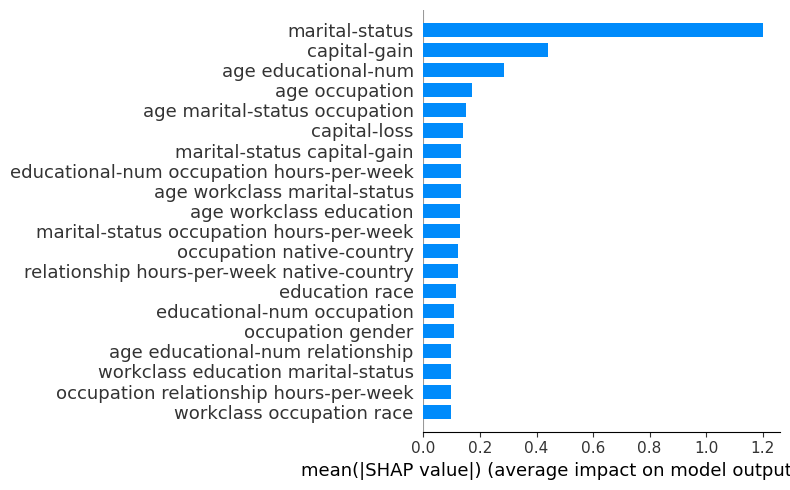

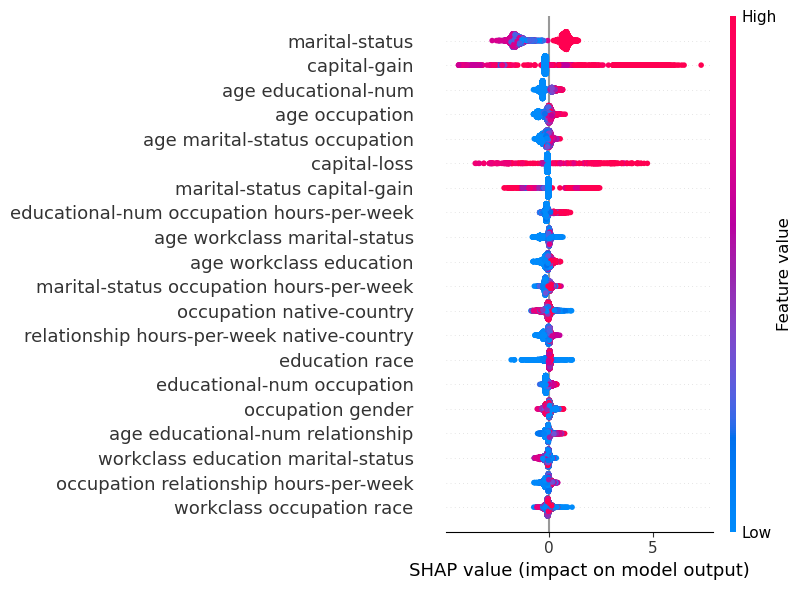

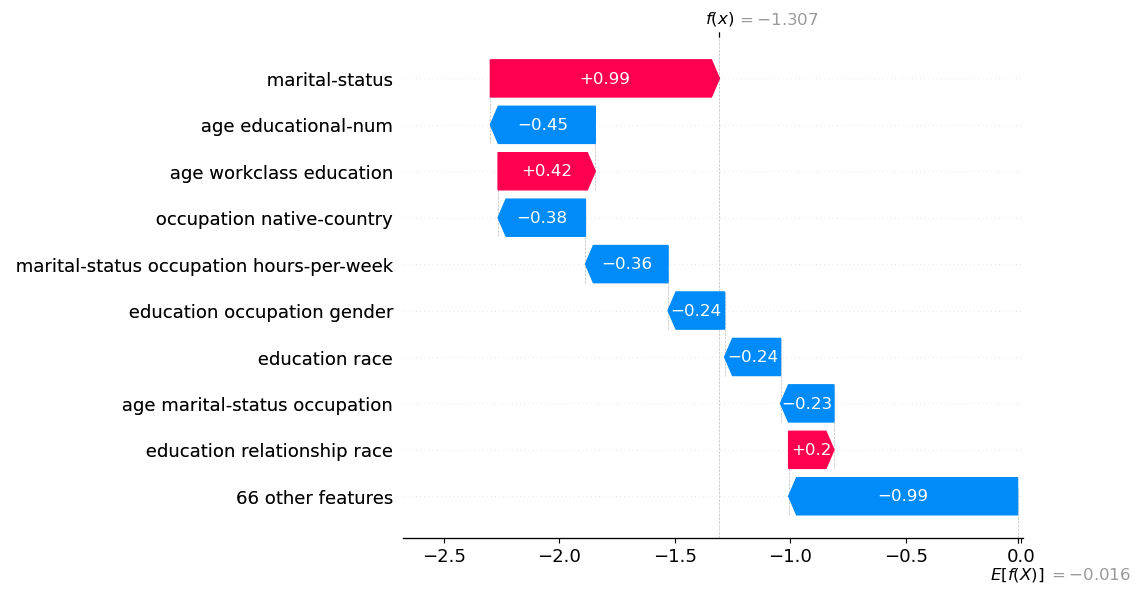

In [80]:
# --- SHAP on reduced XGBoost model (top 75 features) ---

import shap

# Create explainer
explainer_xgb_75 = shap.TreeExplainer(xgb_baseline_xgb_75)

# Compute SHAP values on test set
shap_values_xgb_75 = explainer_xgb_75.shap_values(X_test_xgb_75)

# 1. Global feature importance (bar plot)
shap.summary_plot(
    shap_values_xgb_75,
    X_test_xgb_75,
    plot_type="bar",
    plot_size=(8, 5)
)

# 2. Global direction + spread (beeswarm plot)
shap.summary_plot(
    shap_values_xgb_75,
    X_test_xgb_75,
    plot_size=(8, 6)
)

# 3. Single observation explanation
shap.plots._waterfall.waterfall_legacy(
    explainer_xgb_75.expected_value,
    shap_values_xgb_75[0],
    X_test_xgb_75.iloc[0]
)

### MetaLearner using OOF predictions

In [ ]:
# OOF Stacking Example (RF + XGB → Logistic Regression)
# standalone code cell for reuse as desired

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

# base models
rf = RandomForestClassifier(class_weight="balanced", random_state=42)
xgb = XGBClassifier(scale_pos_weight=spw, eval_metric="logloss", random_state=42)

# meta model
meta_model = LogisticRegression()

# OOF setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# store OOF predictions
rf_oof = np.zeros(len(X_train_fe))
xgb_oof = np.zeros(len(X_train_fe))

# --- Generate OOF predictions ---
for train_idx, val_idx in skf.split(X_train_fe, y_train):
    X_tr, X_val = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    
    # train base models on fold
    rf.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)
    
    # predict validation fold (probabilities for class 1)
    rf_oof[val_idx] = rf.predict_proba(X_val)[:, 1]
    xgb_oof[val_idx] = xgb.predict_proba(X_val)[:, 1]

# --- Train meta model on OOF predictions ---
X_meta_train = np.column_stack((rf_oof, xgb_oof))
meta_model.fit(X_meta_train, y_train)

# --- Retrain base models on FULL training data ---
rf.fit(X_train_fe, y_train)
xgb.fit(X_train_fe, y_train)

# --- Generate test predictions ---
rf_test = rf.predict_proba(X_test_fe)[:, 1]
xgb_test = xgb.predict_proba(X_test_fe)[:, 1]

# --- Meta model final predictions ---
X_meta_test = np.column_stack((rf_test, xgb_test))
meta_preds = meta_model.predict(X_meta_test)

# --- Evaluate ---
print("Stacked Model Balanced Accuracy:",
      balanced_accuracy_score(y_test, meta_preds))

Stacked Model Balanced Accuracy: 0.8169878594503708


In [82]:
# comparing balanced accuracy scores across adult_fe data
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))    
print("Stacked Model Test Balanced Accuracy:", balanced_accuracy_score(y_test, meta_preds))

Random Forest adult_fe Test Balanced Accuracy: 0.8028377756281657
XGBoost adult_fe Test Balanced Accuracy: 0.8407010306050337
Stacked Model Test Balanced Accuracy: 0.8169878594503708


# PyCaret

In [1]:
# PyCaret full workflow on adult_fe data
# Standalone code cell for reuse as desired

from pycaret.classification import *

# combine training features and target for PyCaret
train_fe = X_train_fe.copy()
train_fe["income"] = y_train.values

test_fe = X_test_fe.copy()
test_fe["income"] = y_test.values

# setup experiment
clf_setup = setup(
    data=train_fe,
    target="income",
    session_id=42,
    fold_strategy="stratifiedkfold",
    fold=5,
    numeric_imputation="median",
    categorical_imputation="mode",
    normalize=False,
    silent=True,
    verbose=False
)

# compare models
best_model = compare_models()

# tune best model
tuned_model = tune_model(best_model)

# optional: blend top models
blended_model = blend_models()

# optional: stack top models
stacked_model = stack_models()

# finalize chosen model (pick one: tuned_model, blended_model, or stacked_model)
final_model = finalize_model(stacked_model)

# predict on held-out test set
preds = predict_model(final_model, data=test_fe)

# show results
preds.head()

RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')

# GRAVEYARD

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# importing the data
adult = pd.read_csv("adult.csv")

# 1. Clean Data Values (Crucial for the Adult dataset)
# This removes leading/trailing spaces from the entries themselves
adult = adult.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. Encoding the Target Variable
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# 3. Separate Features and Target
X = adult.drop('income', axis=1)
y = adult['income']

numeric_features = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']

# 4. Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Build the Full Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42))),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 6. Stratified Split (Training/Test)
# stratify=y ensures the 25/75 split is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Stratified Cross-Validation
# shuffle=True and stratify ensures no fold is missing a class
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'feature_selection__estimator__C': [0.1, 1.0],
    'classifier__n_estimators': [100]
}



# 8. Run Workflow
grid_search = GridSearchCV(full_pipeline, param_grid, cv=skf, scoring='accuracy')
grid_search.fit(X_train, y_train)

# --- RESULTS ---
print(f"\nBest CV Accuracy: {grid_search.best_score_:.4f}")

# Identifying the "Kept" Features
selector = grid_search.best_estimator_.named_steps['feature_selection']
feature_names = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
final_features = feature_names[selector.get_support()]

print(f"Features selected by Lasso: {len(final_features)} out of {len(feature_names)}")


In [ ]:
# --- RESULTS SUMMARY ---

best_pipe = grid_search.best_estimator_

print(f"\nBest CV Accuracy: {grid_search.best_score_:.4f}")

# Extract components
selector = best_pipe.named_steps["feature_selection"]
preprocessor = best_pipe.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()
mask = selector.get_support()
final_features = feature_names[mask]

# --- 1. Encoded Features ---
print(f"\nEncoded features selected by Lasso: {len(final_features)} out of {len(feature_names)}")

print("\nSelected encoded features (first 50 shown):")
for f in final_features[:50]:
    print(f)

# --- 2. Map Back to Original Features ---
selected_original_features = set()

for f in final_features:
    if f.startswith("num__"):
        selected_original_features.add(f.replace("num__", ""))
    elif f.startswith("cat__"):
        remainder = f.replace("cat__", "", 1)
        matched = False
        for col in categorical_features:
            prefix = col + "_"
            if remainder.startswith(prefix):
                selected_original_features.add(col)
                matched = True
                break
        if not matched:
            selected_original_features.add(remainder)

all_original_features = set(numeric_features + categorical_features)

# --- 3. Clean Output for Engineering ---
print("\n\n=== ORIGINAL FEATURES KEPT ===")
for f in sorted(selected_original_features):
    print(f)

print(f"\nKept {len(selected_original_features)} out of {len(all_original_features)} original features")

# --- 4. What Was Removed ---
removed_original_features = all_original_features - selected_original_features

print("\n=== ORIGINAL FEATURES REMOVED ===")
for f in sorted(removed_original_features):
    print(f)

# --- 5. Grouped Summary (VERY useful) ---
from collections import defaultdict

grouped = defaultdict(int)

for f in final_features:
    if f.startswith("num__"):
        grouped[f.replace("num__", "")] += 1
    elif f.startswith("cat__"):
        remainder = f.replace("cat__", "", 1)
        for col in categorical_features:
            if remainder.startswith(col + "_"):
                grouped[col] += 1
                break

print("\n=== FEATURE USAGE SUMMARY ===")
for k in sorted(grouped):
    print(f"{k}: {grouped[k]} encoded features selected")